# NB11 figures - trust framework visualisations (item 3)
- For the plots of NB11's spec, from the existing scorecard/disagreement CSVs.
- ig_concordance needs the BiLSTM IG attributions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
BASE = os.getcwd()
NB11 = os.path.join(BASE, "..", "11_clinical_validation_framework")
OUT  = BASE
os.makedirs(OUT, exist_ok=True)
import os; os.makedirs(OUT, exist_ok=True)
score = pd.read_csv(f"{NB11}/scorecard_all_horizons.csv")
print(score.to_string(index=False))

 horizon     method  fidelity  plaus_feat@10  plaus_sign@10  trust_score
      30   TreeSHAP     0.794            0.4           0.75        0.772
      30 KernelSHAP     0.744            0.5           1.00        0.872
      30       LIME     0.482            0.4           0.00        0.241
      60   TreeSHAP     0.809            0.5           1.00        0.905
      60 KernelSHAP     0.755            0.5           1.00        0.877
      60       LIME     0.513            0.5           0.20        0.357
      90   TreeSHAP     0.809            0.4           1.00        0.905
      90 KernelSHAP     0.754            0.5           1.00        0.877
      90       LIME     0.516            0.5           0.20        0.358


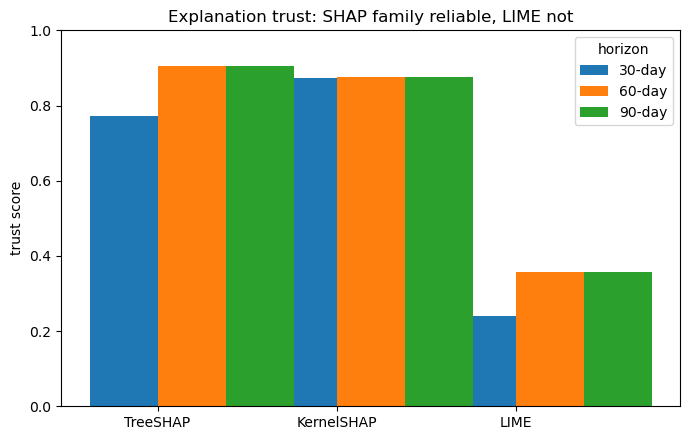

saved: /Users/robert/Desktop/hospital-re-admission/notebooks/11.1_nb11_figures/fig_trust_scorecard.png
saved -> /Users/robert/Desktop/hospital-re-admission/notebooks/11.1_nb11_figures/fig_trust_scorecard.png


In [2]:
# Figure 1: trust score by method and horizon, the headline XAI result.
methods = ["TreeSHAP", "KernelSHAP", "LIME"]
horizons = sorted(score["horizon"].unique())
x = np.arange(len(methods)); w = 0.38
fig, ax = plt.subplots(figsize=(7, 4.5))
for i, h in enumerate(horizons):
    vals = [score[(score.method == m) & (score.horizon == h)]["trust_score"].iloc[0] for m in methods]
    ax.bar(x + (i - 0.5) * w, vals, w, label=f"{h}-day")
ax.set_xticks(x); ax.set_xticklabels(methods)
ax.set_ylabel("trust score"); ax.set_ylim(0, 1); ax.legend(title="horizon")
ax.set_title("Explanation trust: SHAP family reliable, LIME not")
plt.tight_layout(); plt.savefig(f"{OUT}/fig_trust_scorecard.png", dpi=150); plt.show()
print("saved:", OUT + "/fig_trust_scorecard.png")
print("saved ->", os.path.join(OUT, "fig_trust_scorecard.png"))


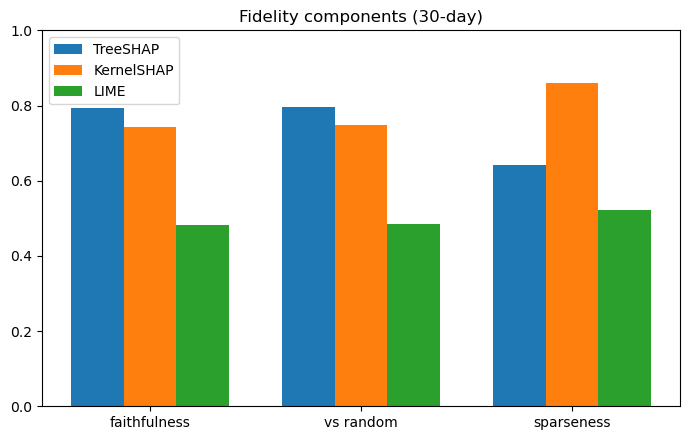

saved: /Users/robert/Desktop/hospital-re-admission/notebooks/11.1_nb11_figures/fig_fidelity.png
saved -> /Users/robert/Desktop/hospital-re-admission/notebooks/11.1_nb11_figures/fig_fidelity.png


In [3]:
# Figure 2: fidelity components by method (30-day).
fid = pd.read_csv(f"{NB11}/fidelity_h30.csv")
cols = ["faithfulness_corr", "vs_random", "sparseness"]
x = np.arange(len(cols)); w = 0.25
fig, ax = plt.subplots(figsize=(7, 4.5))
for i, m in enumerate(methods):
    row = fid[fid.method == m][cols].iloc[0].values
    ax.bar(x + (i - 1) * w, row, w, label=m)
ax.set_xticks(x); ax.set_xticklabels(["faithfulness", "vs random", "sparseness"])
ax.set_ylim(0, 1); ax.legend(); ax.set_title("Fidelity components (30-day)")
plt.tight_layout(); plt.savefig(f"{OUT}/fig_fidelity.png", dpi=150); plt.show()
print("saved:", OUT + "/fig_fidelity.png")
print("saved ->", os.path.join(OUT, "fig_fidelity.png"))


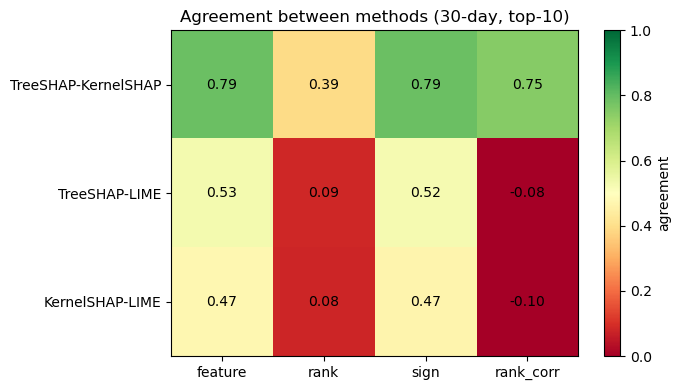

saved: /Users/robert/Desktop/hospital-re-admission/notebooks/11.1_nb11_figures/fig_disagreement_heatmap.png
saved -> /Users/robert/Desktop/hospital-re-admission/notebooks/11.1_nb11_figures/fig_disagreement_heatmap.png


In [4]:
# Figure 3: method-disagreement heatmap (30-day, top-10 features).
dis = pd.read_csv(f"{NB11}/disagreement_h30.csv")
d = dis[dis["K"] == 10]
measures = ["feature", "rank", "sign", "rank_corr"]
pairs = ["TreeSHAP-KernelSHAP", "TreeSHAP-LIME", "KernelSHAP-LIME"]
M = np.array([[d[(d.pair == p) & (d.measure == ms)]["mean"].iloc[0] for ms in measures] for p in pairs])
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(M, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(measures))); ax.set_xticklabels(measures)
ax.set_yticks(range(len(pairs))); ax.set_yticklabels(pairs)
for i in range(len(pairs)):
    for j in range(len(measures)):
        ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center")
ax.set_title("Agreement between methods (30-day, top-10)")
plt.colorbar(im, label="agreement")
plt.tight_layout(); plt.savefig(f"{OUT}/fig_disagreement_heatmap.png", dpi=150); plt.show()
print("saved:", OUT + "/fig_disagreement_heatmap.png")
print("saved ->", os.path.join(OUT, "fig_disagreement_heatmap.png"))
